# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Woodie's Range Trading Strategy

In the previous units, you learnt how to compute and visualise the Woodie's pivot levels for the weekly frequency data. Further, you were also introduced to a unique strategy based on the principles of range trading. In this notebook, you will learn to implement the same in a step-by-step manner using Python.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Import the Data](#data)
3. [Resample the Data](#resample)
4. [Calculate the Woodie's Pivot Points](#pivots)
5. [Merge the Data](#merge)
6. [Generate the Trading Signals](#signals)
7. [Backtest the Strategy](#backtest)
8. [Trade Level Analytics](#trade-level-analytics)
9. [Strategy Performance](#performance)
10. [Summary and Next Steps](#summary)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# Ignore warnings
import warnings 
warnings.filterwarnings('ignore')

# For datetime manipulation
from datetime import timedelta

# Import utility functions 
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import backtester, trade_level_analytics, get_performance_metrics

<a id='data'></a>
## Import the Data

From the `data_modules` folder, let's import the minute-wise price data of the Apple stock which is stored in a CSV file named `apple_1_minute_2015_2021.csv`. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

We will use the `read_csv` method of `pandas` to import the data and then store it in a dataframe named `data`.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Print first 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='resample'></a>
## Resample the Data

For the range trading strategy using Woodie's Pivots, we would need the resampled data in weekly, daily and 15-min frequencies. 

The weekly resampled data will be used for calculating the Woodie's pivots, since the Woodie's pivots work well on longer timeframes. 

The daily and the 15-min resampled data, on the other hand, would be used for checking strategy-related conditions and for determining the entry and exit signals. For now, let's proceed with resampling the minute level data.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
             }

# Fetch the weekly resampled data
data_weekly = data.resample('W-FRI', label='right', closed='right').agg(ohlcv_dict).dropna()
data_weekly.index += timedelta(hours=16, minutes=0)

# Fetch the daily resampled data
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=9, minutes=30)

# Fetch and display the 15-min resampled data
data_15 = data.resample('15min', label='right', closed='right').agg(ohlcv_dict).dropna()
data_15.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.8000,27.8100
2015-01-02 09:45:00+00:00,27.8100,27.8525,27.6375,27.6475
2015-01-02 10:00:00+00:00,27.6500,27.6625,27.1625,27.3750
2015-01-02 10:15:00+00:00,27.3750,27.4800,27.3000,27.3175
2015-01-02 10:30:00+00:00,27.3175,27.3375,27.1925,27.2800


In [4]:
# Display the daily data
data_daily.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,26.8375,27.3250
2015-01-05 09:30:00+00:00,27.0725,27.1625,26.3525,26.5625
2015-01-06 09:30:00+00:00,26.6700,26.8575,26.1575,26.5575
2015-01-07 09:30:00+00:00,26.7950,27.0500,26.6750,26.9375
2015-01-08 09:30:00+00:00,27.3075,28.0375,27.1750,27.9675


In [5]:
# Display the weekly data
data_weekly.head()

,Open,High,Low,Close
2015-01-02 16:00:00+00:00,27.8475,27.8600,26.8375,27.3250
2015-01-09 16:00:00+00:00,27.0725,28.3125,26.1575,28.0000
2015-01-16 16:00:00+00:00,28.1575,28.2000,26.3000,26.4950
2015-01-23 16:00:00+00:00,26.9650,28.4375,26.6250,28.2475
2015-01-30 16:00:00+00:00,28.4075,30.0000,27.2575,29.2900


<a id='pivots'></a>
## Calculate the Woodie's Pivot Points

The following code for computing Woodie's pivots is the same as we have already learned in the previous notebook. 
Note that we will compute the Woodie's pivots based on the weekly frequency.

In [6]:
# Initialise the previous high, low, close
prev_high = data_weekly['High'].shift(1)
prev_low = data_weekly['Low'].shift(1)
prev_close = data_weekly['Close'].shift(1)

# Calculate the Woodie's pivot level
data_weekly['W-Pivot'] = (prev_high + prev_low + (2*prev_close))/4

# Calculate the Woodie's resistance levels
data_weekly['R1'] = 2*data_weekly['W-Pivot'] - prev_low
data_weekly['R2'] = data_weekly['W-Pivot'] + (prev_high - prev_low)
data_weekly['R3'] = prev_high + 2*(data_weekly['W-Pivot'] - prev_low)

# Calculate the Woodie's support levels
data_weekly['S1'] = 2 * data_weekly['W-Pivot'] - prev_high
data_weekly['S2'] = data_weekly['W-Pivot'] - (prev_high - prev_low)
data_weekly['S3'] = prev_low - 2*(prev_high - data_weekly['W-Pivot'])

# Drop all NaN values from the dataframe
data_weekly.dropna(axis=0, how='any', inplace=True)

# Display the data
data_weekly.head()

,Open,High,Low,Close,W-Pivot,R1,R2,R3,S1,S2,S3
2015-01-09 16:00:00+00:00,27.0725,28.3125,26.1575,28.0000,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-16 16:00:00+00:00,28.1575,28.2000,26.3000,26.4950,27.617500,29.07750,29.772500,31.23250,26.92250,25.462500,24.76750
2015-01-23 16:00:00+00:00,26.9650,28.4375,26.6250,28.2475,26.872500,27.44500,28.772500,29.34500,25.54500,24.972500,23.64500
2015-01-30 16:00:00+00:00,28.4075,30.0000,27.2575,29.2900,27.889375,29.15375,29.701875,30.96625,27.34125,26.076875,25.52875
2015-02-06 16:00:00+00:00,29.5100,30.1275,29.0200,29.7275,28.959375,30.66125,31.701875,33.40375,27.91875,26.216875,25.17625


<a id='merge'></a>
## Merge the Data

In the following cells, you will learn to merge and organise the data of multiple frequencies for Apple into a single dataframe. Presently, we are working with the weekly, daily and the 15-Minute frequency data. 

Since the Woodie's pivots are computed based on the weekly frequency data, we will only require the data of pivot points from `data_weekly`.

In [7]:
# Shortlist columns and prepare data_weekly for merging
data_weekly = data_weekly[['W-Pivot', 'R1',
                           'R2', 'R3', 'S1', 'S2', 'S3']]

Further, if you recall from the video where we demonstrated the strategy logic, we also checked for two additional conditions to assess the likelihood of a range bound movement. The two conditions were: (Day's Open < R2) and (Day's Open > S2). This means, we will only require the `Open` data points from the dataframe `data_daily` to check for these conditions.

In [8]:
# Shortlist and prepare the data_daily for merging
data_daily = data_daily[['Open']]

# Rename the column to avoid duplicates
data_daily.columns = ['Open_daily']

And finally, we can carefully merge all of the above data with the 15-Minute dataframe and store all of it in a new dataframe `strategy_data`. The data corresponding to the 15-Minute timeframe will be used to generate your entry and exit signals.

In [9]:
# Merge the daily data with the 15-min data and store results in a dataframe strategy_data
strategy_data = pd.merge(
    data_15, data_daily, left_index=True, right_index=True, how='left')

# Forward fill the day's open to all the 15-min data for a given day
strategy_data = strategy_data.fillna(method='ffill')
strategy_data.head()

,Open,High,Low,Close,Open_daily
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.8000,27.8100,27.8475
2015-01-02 09:45:00+00:00,27.8100,27.8525,27.6375,27.6475,27.8475
2015-01-02 10:00:00+00:00,27.6500,27.6625,27.1625,27.3750,27.8475
2015-01-02 10:15:00+00:00,27.3750,27.4800,27.3000,27.3175,27.8475
2015-01-02 10:30:00+00:00,27.3175,27.3375,27.1925,27.2800,27.8475


Next, we will merge the `data_weekly` so that the pivot levels calculated on weekly can be referred for the entirety of the week. That is, we will freeze the pivot levels obtained on Monday until the last trading day of the week, i.e. Friday.

In [10]:
# Merge the data of weekly Woodie's pivots to the new dataframe strategy_data
strategy_data = pd.merge(strategy_data, data_weekly,
                         left_index=True, right_index=True, how='left')

# Forward fill the pivot levels for all the trading days in the same week
strategy_data = strategy_data.fillna(method='ffill')

# Drop the NaN values and display the data
strategy_data.dropna(axis=0, how='any', inplace=True)
strategy_data.head()

,Open,High,Low,Close,Open_daily,W-Pivot,R1,R2,R3,S1,S2,S3
2015-01-09 16:00:00+00:00,28.0325,28.0625,27.9875,28.0000,28.1675,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 09:30:00+00:00,28.1575,28.1600,28.0300,28.0300,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 09:45:00+00:00,28.0325,28.1500,27.6700,27.7975,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 10:00:00+00:00,27.7975,27.8425,27.5500,27.5750,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 10:15:00+00:00,27.5725,27.5775,27.3400,27.4925,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125


Note that in the dataframe shown above, the data starts from 2015-01-09 onwards. 

However, earlier when we merged `data_15` and `data_daily`, we had data available for the dates from 2015-01-02 onwards. 
So the question here is: Why is the data for the first week missing?

The data is missing because for the very first week, you would not be able to compute the weekly Woodie's as there was no past data available at that point in time. And going further, while merging the `data_weekly` with the `strategy_data`, we ensured that all rows with `NaN` values were dropped from the dataframe.

<a id='signals'></a>
## Generate the Trading Signals

In the following cells, you will learn to determine a range trading signal. Firstly, a column named `range_signal` can be created to assess whether there is a likelihood of a range bound movement. You can check for the following two conditions, to evaluate the same.
1. Day's Open < Week's R2 
2. Day's Open > Week's S2

Whenever both the above conditions are met, you can assign a value of `1` for the `range_signal`.

In [11]:
# Specify the conditions for range trading
cond_1 = strategy_data['Open_daily'] < strategy_data['R2']
cond_2 = strategy_data['Open_daily'] > strategy_data['S2']

# Generate signal values based on the above conditions
strategy_data['range_signal'] = np.where(cond_1 & cond_2, 1, 0)

Secondly, we will generate the `entry signal`. Since S2 is selected to be our buying level, we will check for a 15-min close occurring below the S2 level. 
* If a 15-min candle closes below S2, then the `entry_signal` = `1` 
* Otherwise, the `entry_signal` = `0`

In [12]:
# Check 15-min close below S2 level
strategy_data['entry_signal'] = np.where(
    strategy_data['Close'] <= strategy_data['S2'], 1, 0)

### Final Trading Signal

We will only take trades if both the `range_signal` as well as the `entry_signal` hold true (i.e value of both equals 1).

In [13]:
# Determine the value of the final trading signal
strategy_data['signal'] = strategy_data['range_signal'] * \
    strategy_data['entry_signal']

### Risk Management

Finally, we will set the exit levels for our strategy. The `stoploss` can be placed at the average of S2 and S3 levels. And similarly, the W-Pivot level can be set as the `target` price where we can expect to exit the trade with a profit.

In [14]:
# Determine the stop-loss level
strategy_data['stoploss'] = (strategy_data['S2'] + strategy_data['S3'])/2

# Determine the take-profit level
strategy_data['target'] = strategy_data['W-Pivot']

<a id='backtest'></a>
## Backtest the Strategy

In the following cells, we will backtest the range trading strategy by using the `backtester` function as we have done for previous strategies. This function will generate a detailed trade sheet for this strategy.

In [15]:
tradesheet = backtester(strategy_data)

Trade No: 1 | Entry Date: 2015-03-05 13:00:00+00:00 | Entry Price: 31.47 | Position: 1
Exit Type: TP | Exit Date: 2015-03-06 10:00:00+00:00 | Exit Price: 32.33 | PnL: 0.86 | Cum PnL: 0.86
------------------------------
Trade No: 2 | Entry Date: 2015-03-11 10:45:00+00:00 | Entry Price: 30.56 | Position: 1
Exit Type: TP | Exit Date: 2015-04-23 10:00:00+00:00 | Exit Price: 32.35 | PnL: 1.79 | Cum PnL: 2.65
------------------------------
Trade No: 3 | Entry Date: 2015-07-07 11:30:00+00:00 | Entry Price: 31.0 | Position: 1
Exit Type: SL | Exit Date: 2015-07-08 10:15:00+00:00 | Exit Price: 30.81 | PnL: -0.19 | Cum PnL: 2.46
------------------------------
Trade No: 4 | Entry Date: 2015-07-08 10:30:00+00:00 | Entry Price: 30.83 | Position: 1
Exit Type: SL | Exit Date: 2015-07-08 12:00:00+00:00 | Exit Price: 30.81 | PnL: -0.02 | Cum PnL: 2.44
------------------------------
Trade No: 5 | Entry Date: 2015-07-08 12:15:00+00:00 | Entry Price: 30.85 | Position: 1
Exit Type: SL | Exit Date: 2015-07-0

As shown above, we have obtained a decent trade log which helps us understand the nature of each of the trades that were executed. 

For example, the very last long position was opened on 2020-09-18 at 12:45 pm. This long position was then exited on 2020-12-09 at 09:45 am as the take-profit (TP) level was hit. Hence, there is a PnL of $18.12 associated with this particular trade.

<a id='trade-level-analytics'></a>
## Trade Level Analytics

While calculating the PnL, we were only concerned with the entry and exit time. To calculate analytics, we will forward-fill the signal column with the position taken to get a clear idea of the strategy performance.

In [16]:
tradesheet.index = range(0, len(tradesheet))
strategy_data.signal = 0

# Iterate over each row in the 'trades' DataFrame
for index, trade in tradesheet.iterrows():
    # Extract the entry date of the trade
    entry_time = tradesheet['entry_date'][index]
    
    # Extract the exit date of the trade
    exit_time = tradesheet['exit_date'][index]
    
    # Extract the position of the trade (e.g., -1 for short)
    position = tradesheet['position'][index]
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    strategy_data.loc[entry_time:exit_time, 'signal'] = position

Using the `trade_level_analytics()` function,  calculate the trade level analytics.

In [17]:
# Trade level analytics
trade_level_analytics(tradesheet)

,Strategy
Total PnL,16.13
total_trades,55
Number of Winners,20
Number of Losers,35
Win (%),36.363636
Loss (%),63.636364
per_trade_PnL_winners,1.791
per_trade_PnL_losers,0.562571
Average holding time,4 days 10:30:16.363636363
Profit Factor,1.819198


The Woodie's range trading strategy generated 55 trades over the backtested period out of which 20 were profitable trades. And you can also see that the strategy's win percentage is higher than the loss percentage, resulting in a positive profit factor of 1.81.

<a id='performance'></a>
## Strategy Performance
Analyse the strategy's performance by using the `get_performance_metrics()` function.

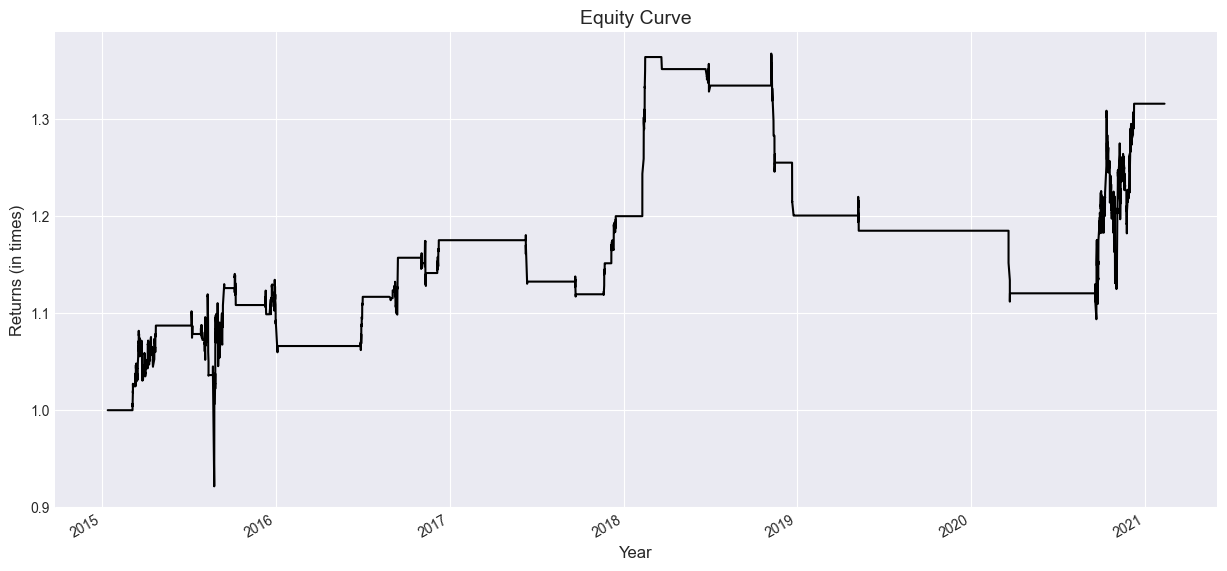

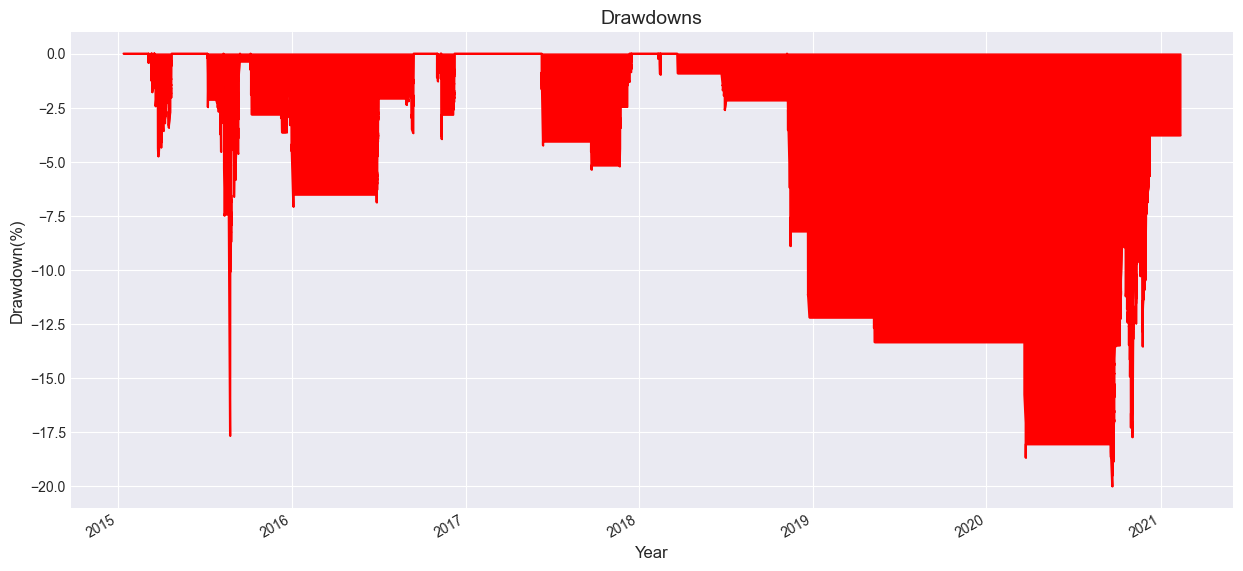

                 Strategy
CAGR                4.67%
Sharpe Ratio         0.29
Maximum Drawdown  -20.01%


In [18]:
# Strategy performance
get_performance_metrics(strategy_data)

Over the backtested period, the strategy generated a CAGR of 4.67% with a Sharpe ratio of 0.29 and a maximum drawdown limited to -20.01%.

<a id='summary'></a>
## Summary and Next Steps

You have successfully created and backtested a range trading strategy based on the weekly Woodie's. 

Note that certain parameters, such as the frequency of data chosen for generating trading signals ('15m'), as well as the entry and exit conditions (such as stop-loss and take-profit levels) have been chosen arbitrarily.

You can tweak all of these parameters to understand how the nature of the trades changes. And further, you can also download and test this strategy on any other asset that you prefer. <br><br>